In [17]:
#download mosaics and catalogs for the CEERS field and unzip
import os
if not os.path.exists('hlsp_ceers_jwst_nircam_fullceers_f150w_v1_sci-bkgsub.fits'):
    ! wget https://web.corral.tacc.utexas.edu/ceersdata/DR1/NIRCam/fullceers/hlsp_ceers_jwst_nircam_fullceers_f150w_v1_sci-bkgsub.fits.gz
    ! gunzip hlsp_ceers_jwst_nircam_fullceers_f150w_v1_sci-bkgsub.fits.gz
    ! rm hlsp_ceers_jwst_nircam_fullceers_f150w_v1_sci-bkgsub.fits.gz

if not os.path.exists('ceers_cat_v1.0.fits'):
    ! wget https://web.corral.tacc.utexas.edu/ceersdata/DR1/Catalog/ceers_cat_v1.0.fits.gz
    ! gunzip ceers_cat_v1.0.fits.gz
    ! rm ceers_cat_v1.0.fits.gz

In [18]:
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import numpy as np

full_cat = Table.read('ceers_cat_v1.0.fits')
full_cat.info()

<Table length=87345>
         name           dtype  shape    class     n_bad
---------------------- ------- ----- ------------ -----
                NUMBER   int32             Column     0
               X_IMAGE float32             Column     0
               Y_IMAGE float32             Column     0
                    RA float32             Column     0
                   DEC float32             Column     0
             CXX_IMAGE float32             Column     0
             CXY_IMAGE float32             Column     0
             CYY_IMAGE float32             Column     0
           THETA_IMAGE float32             Column     0
           ELLIPTICITY float32             Column     0
           KRON_RADIUS float32             Column     0
               A_IMAGE float32             Column     0
               B_IMAGE float32             Column     0
              ISO_AREA float32             Column     0
             STAR_FLAG float32             Column     0
       BAD_REGION_FLAG floa

NUMBER  X_IMAGE  Y_IMAGE     RA      DEC    CXX_IMAGE CXY_IMAGE CYY_IMAGE THETA_IMAGE ELLIPTICITY KRON_RADIUS A_IMAGE B_IMAGE ISO_AREA STAR_FLAG BAD_REGION_FLAG APCORR_TOTAL F115W_FLUX F115W_FLUXERR_SE F115W_FLUXERR_EMP F115W_MAG F115W_MAGERR_SE F115W_MAGERR_EMP     F115W_FLUX_APER     F115W_FLUXERR_APER_SE  F115W_FLUXERR_APER_EMP F115W_CLASS_STAR F115W_FLUX_RADIUS F150W_FLUX F150W_FLUXERR_SE F150W_FLUXERR_EMP F150W_MAG F150W_MAGERR_SE F150W_MAGERR_EMP     F150W_FLUX_APER     F150W_FLUXERR_APER_SE F150W_FLUXERR_APER_EMP F150W_CLASS_STAR F150W_FLUX_RADIUS F200W_FLUX F200W_FLUXERR_SE F200W_FLUXERR_EMP F200W_MAG F200W_MAGERR_SE F200W_MAGERR_EMP    F200W_FLUX_APER     F200W_FLUXERR_APER_SE   F200W_FLUXERR_APER_EMP F200W_CLASS_STAR F200W_FLUX_RADIUS F277W_FLUX F277W_FLUXERR_SE F277W_FLUXERR_EMP F277W_MAG F277W_MAGERR_SE F277W_MAGERR_EMP    F277W_FLUX_APER     F277W_FLUXERR_APER_SE   F277W_FLUXERR_APER_EMP F277W_CLASS_STAR F277W_FLUX_RADIUS F356W_FLUX F356W_FLUXERR_SE F356W_FLUXERR_EMP F356W

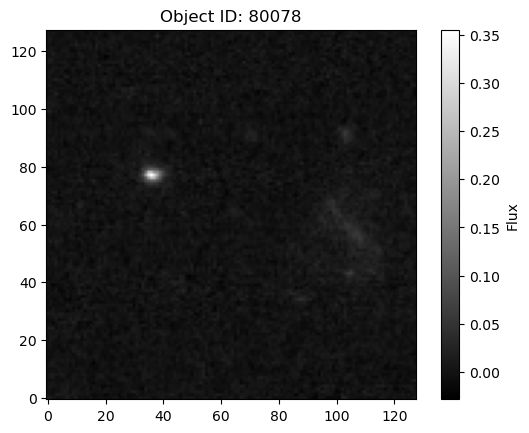

In [72]:
from astropy.coordinates import SkyCoord
import astropy.units as u

with fits.open('hlsp_ceers_jwst_nircam_fullceers_f150w_v1_sci-bkgsub.fits') as hdul:
    #WCS info is in the header of the first extension
    wcs = WCS(hdul[1].header)
    #from radec to pixel (pack RA/DEC into a single SkyCoord for the high-level API)
    coords = SkyCoord(full_cat['RA'], full_cat['DEC'], unit='deg')
    x, y = wcs.world_to_pixel(coords)
    #visualize one random object
    idx = np.random.randint(len(full_cat))
    print(full_cat[idx])
    print(f'x: {x[idx]}, y: {y[idx]}')
    #plot the object cutout
    cutout_size = 64
    cutout = hdul[1].data[int(y[idx]-cutout_size):int(y[idx]+cutout_size), int(x[idx]-cutout_size):int(x[idx]+cutout_size)]
    plt.imshow(cutout, origin='lower', cmap='gray')
    plt.title(f'Object ID: {full_cat["NUMBER"][idx]}')
    plt.colorbar(label='Flux')
    plt.show()
    